In [1]:
library(Seurat)
library(escape)
library(dplyr)
library(ggplot2)
library(ggnewscale)
library(scRepertoire)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


In [2]:
so <- readRDS('seurat_objects/reflex_vst4_so.rds')

In [3]:
so

An object of class Seurat 
18129 features across 128091 samples within 1 assay 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [4]:
table(so$orig.ident)


       D0_2164        D0_3446 D10_2164_CEFSX   D10_2164_EBV  D10_2164_null 
         17398          21683          14273          15112          19288 
D10_3446_CEFSX   D10_3446_EBV  D10_3446_null 
         14296          12906          13135 

In [5]:
so <- SetIdent(so, value = 'orig.ident')
so <- RenameIdents(so,
                  'D0_2164' = 'Day_0',
                  'D0_3446' = 'Day_0',
                  'D10_2164_CEFSX' = 'Day_10',
                  'D10_2164_EBV' = 'Day_10',
                  'D10_2164_null' = 'Day_10',
                  'D10_3446_CEFSX' = 'Day_10',
                  'D10_3446_EBV' = 'Day_10',
                  'D10_3446_null' = 'Day_10')
so$Day <- Idents(so)

In [6]:
so <- SetIdent(so, value = 'orig.ident')
so <- RenameIdents(so,
                  'D0_2164' = 'Null',
                  'D0_3446' = 'Null',
                  'D10_2164_CEFSX' = 'CEFSX',
                  'D10_2164_EBV' = 'EBV',
                  'D10_2164_null' = 'Null',
                  'D10_3446_CEFSX' = 'CEFSX',
                  'D10_3446_EBV' = 'EBV',
                  'D10_3446_null' = 'Null')
so$Peptide <- Idents(so)

In [7]:
so <- SetIdent(so, value = 'orig.ident')
so <- RenameIdents(so,
                  'D0_2164' = '2164',
                  'D0_3446' = '3446',
                  'D10_2164_CEFSX' = '2164',
                  'D10_2164_EBV' = '2164',
                  'D10_2164_null' = '2164',
                  'D10_3446_CEFSX' = '3446',
                  'D10_3446_EBV' = '3446',
                  'D10_3446_null' = '3446')
so$Donor <- Idents(so)

In [8]:
sort(colnames(so@meta.data))

[1] "CTaa"              "CTgene"            "CTnt"             
 [4] "CTstrict"          "Day"               "Donor"            
 [7] "Doublet_Score"     "L1"                "L2"               
[10] "L3"                "Peptide"           "Predicted_Doublet"
[13] "RNA_snn_res.0.5"   "barcodes"          "clonalFrequency"  
[16] "clonalProportion"  "cloneSize"         "nCount_RNA"       
[19] "nFeature_RNA"      "orig.ident"        "percent.mt"       
[22] "sample_barcode"    "sample_name"       "seurat_clusters"

In [9]:
t_cells <- subset(so, L1 == 'T cell')

In [10]:
t_cells <- NormalizeData(t_cells) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% 
    RunUMAP(dims=1:30) %>% FindNeighbors(dims=1:30) %>% FindClusters(resolution=0.8)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  TSC22D3, IL7R, TNFAIP3, DUSP1, LTB, NELL2, KLF2, FCMR, KLRB1, TCF7 
	   IL6R, BTG2, AHNAK, NR4A2, KLRG1, JUN, FCRL6, SYNE1, SLC35D2, MX2 
	   LYZ, CD69, ADGRG1, EPHA1, ANK3, PDE4B, FGR, DUSP2, PLXND1, ASTL 
Negative:  TYMS, CDK1, H1-5, RRM2, H2BC9, MKI67, TUBA1B, HMGB2, KIFC1, NUSAP1 
	   TOP2A, H4C3, TPX2, FOXM1, MYBL2, NCAPG, HJURP, CKS1B, TK1, FANCI 
	   PCLAF, CENPM, SMC4, ASF1B, UHRF1, SPC25, NCAPG2, TACC3, KIF11, H2AX 
PC_ 2 
Positive:  SRGN, IL2RA, LAG3, CD82, DUSP4, ADAM19, CCR4, CD4, VDR, MAF 
	   RDH10, LGALS1, SEC11C, IL2RB, PIM2, ELAPOR1, FURIN, HAVCR2, CD40LG, CMTM6 
	   PRDM1, DUSP16, TNFRSF1B, BHLHE40, CD2, DUSP6, ENTPD1, RUNX2, HNRNPLL, CTLA4 
Negative:  DACT1, TCF7, IGSF11, PHGDH, RRS1, ELAPOR2, H1-5, H3C8, PECAM1, HJURP 
	   FOS, SPC25, PLXNA4, H2BC9, LEF1,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 105457
Number of edges: 3251701

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8900
Number of communities: 23
Elapsed time: 37 seconds


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



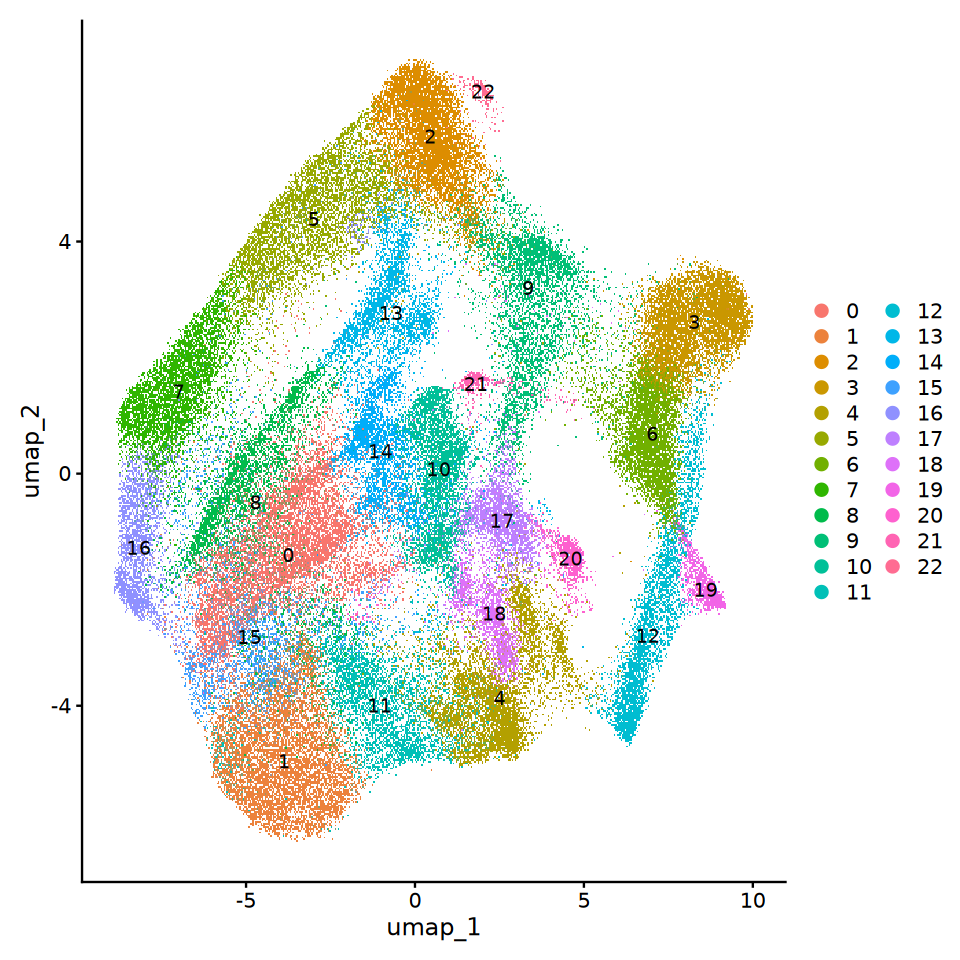

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



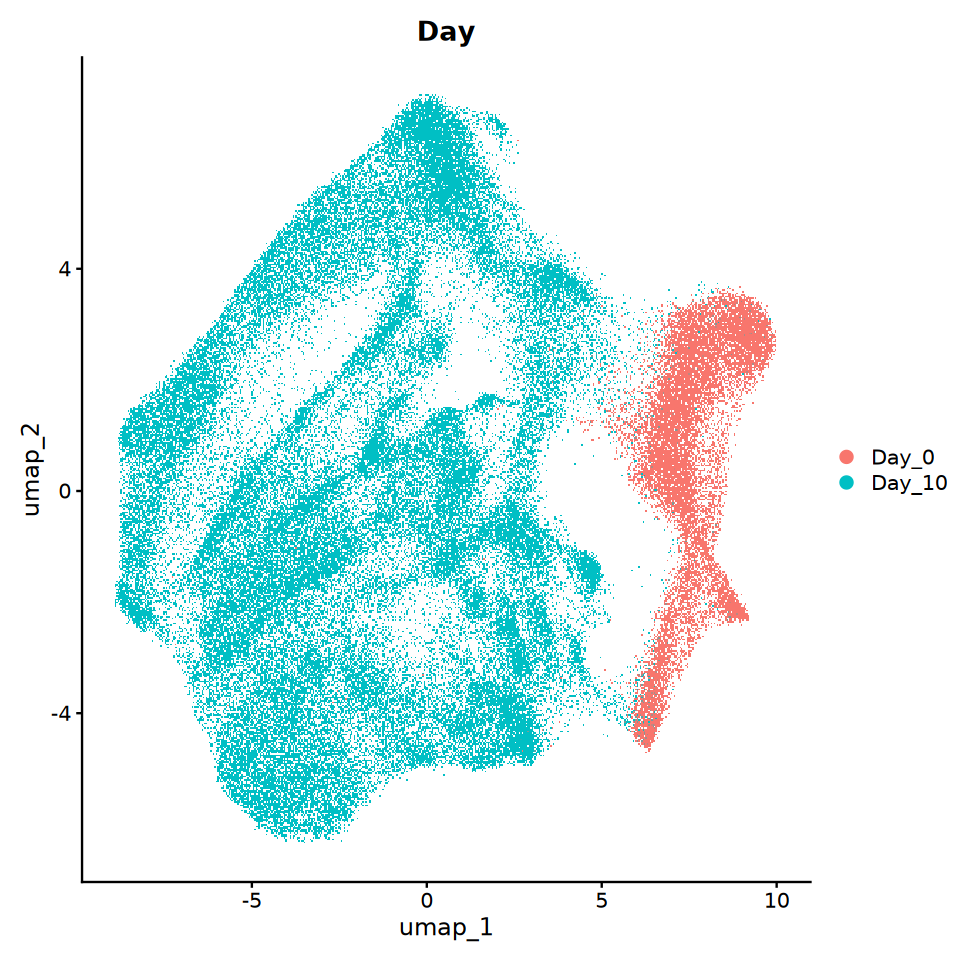

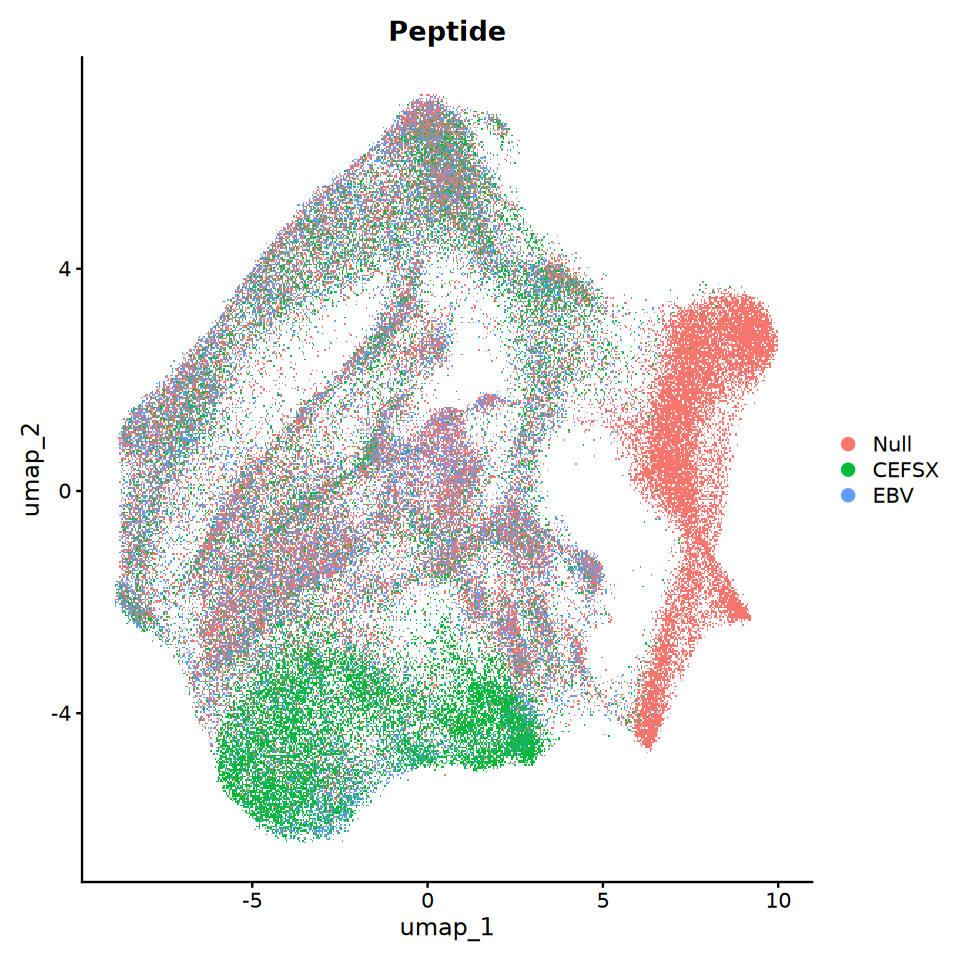

In [11]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(t_cells, label = T)
DimPlot(t_cells, group.by = 'Day')
DimPlot(t_cells, group.by = 'Peptide')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



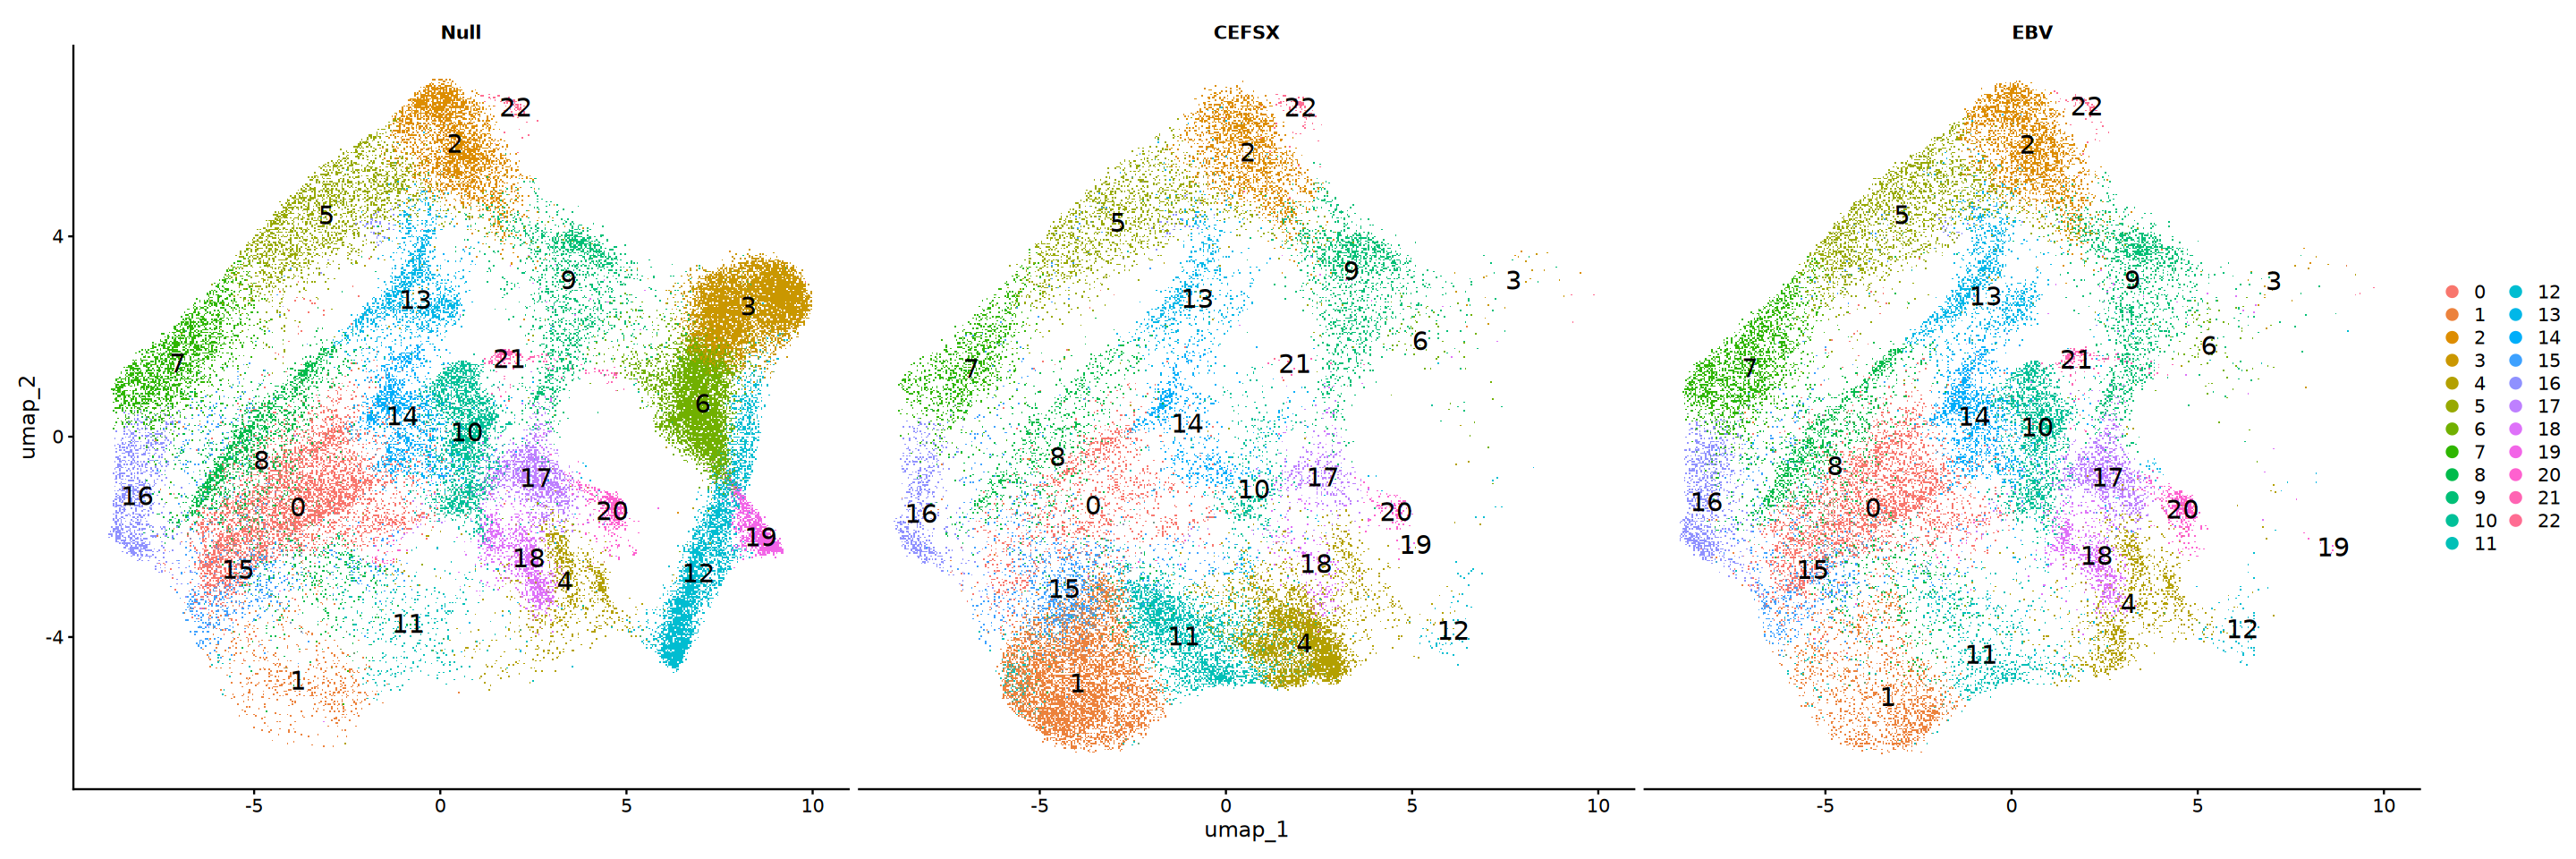

In [12]:
options(repr.plot.width = 24, repr.plot.height = 8)
DimPlot(t_cells, split.by = 'Peptide', label = T, label.size = 6)

# Clean up data for Alignment

In [13]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [14]:
so$CTgene_archive <- so$CTgene

In [15]:
so@meta.data <- so@meta.data %>%
  mutate(
    CTgene = str_remove_all(CTgene_archive, "\\*[A-Za-z0-9]+\\([0-9.]+\\)")
  )

In [16]:
head(so$CTgene_archive)

AAACAAGCAACTAAGTACAGTCTG-1 
"TRAV13-1*00(1364.3).TRAJ45*00(534.8).TRAC*00(74.9)_TRBV19*00(940.1).TRBD1*00(55).TRBJ1-4*00(454.7).TRBC1*00(261.5)" 
                                                                                          AAACAAGCAAGCGATCACTTTAGG-1 
                                                                                                                  NA 
                                                                                          AAACAAGCAATAAGGAACTTTAGG-1 
                                                                                                                  NA 
                                                                                          AAACAAGCACCACATTACAGTCTG-1 
                                                                                                                  NA 
                                                                                          AAACAAGCACTCCCAAACAGTCTG-1 
  "TRAV4*00(724.7).TRAJ12*00(577.3).TRAC*00(353.4)_TRBV6-5*00(833.8).TRBD1*00(35).TRBJ1-5*00(474.8).TRBC1*00(317.4)" 
                                                                                          AAACAAGCACTCCCAAACTTTAGG-1 
                                                                                                                  NA

In [17]:
head(so$CTgene)

AAACAAGCAACTAAGTACAGTCTG-1 
"TRAV13-1.TRAJ45.TRAC_TRBV19.TRBD1.TRBJ1-4.TRBC1" 
                       AAACAAGCAAGCGATCACTTTAGG-1 
                                               NA 
                       AAACAAGCAATAAGGAACTTTAGG-1 
                                               NA 
                       AAACAAGCACCACATTACAGTCTG-1 
                                               NA 
                       AAACAAGCACTCCCAAACAGTCTG-1 
  "TRAV4.TRAJ12.TRAC_TRBV6-5.TRBD1.TRBJ1-5.TRBC1" 
                       AAACAAGCACTCCCAAACTTTAGG-1 
                                               NA

In [18]:
t_cells@meta.data <- t_cells@meta.data %>%
  mutate(
    # 1. Extract everything before the LAST underscore
    CDR3a = str_replace(CTaa, "_[^_]+$", ""),
    
    # 2. Extract everything after the LAST underscore
    CDR3b = str_extract(CTaa, "[^_]+$")
  ) %>%
  mutate(
    # 3. Clean up the literal "NA" strings to be actual R NAs
    CDR3a = ifelse(CDR3a == "NA", NA_character_, CDR3a),
    CDR3b = ifelse(CDR3b == "NA", NA_character_, CDR3b)
  )

In [19]:
head(t_cells$CTaa)

AAACAAGCAACTAAGTACAGTCTG-1            AAACAAGCACTCCCAAACAGTCTG-1 
"CAASIGNQ_GGADGLTF_CASSAARDRSGNEKLFF"      "CLVVTMDSSYKLIF_CASSMTGNGNQPQHF" 
           AAACAAGCATATAGGTACAGTCTG-1            AAACAAGCATGAGTCAACAGTCTG-1 
                    "CAVTGGGSRLTF_NA"                                    NA 
           AAACCAATCATTAGTCACAGTCTG-1            AAACCAGGTCATGAAGACTTTAGG-1 
                                   NA                    "CATDTSGTYKYIF_NA"

In [20]:
head(t_cells$CDR3a)

AAACAAGCAACTAAGTACAGTCTG-1 AAACAAGCACTCCCAAACAGTCTG-1 
       "CAASIGNQ_GGADGLTF"           "CLVVTMDSSYKLIF" 
AAACAAGCATATAGGTACAGTCTG-1 AAACAAGCATGAGTCAACAGTCTG-1 
            "CAVTGGGSRLTF"                         NA 
AAACCAATCATTAGTCACAGTCTG-1 AAACCAGGTCATGAAGACTTTAGG-1 
                        NA            "CATDTSGTYKYIF"

In [21]:
head(t_cells$CDR3b)

AAACAAGCAACTAAGTACAGTCTG-1 AAACAAGCACTCCCAAACAGTCTG-1 
       "CASSAARDRSGNEKLFF"          "CASSMTGNGNQPQHF" 
AAACAAGCATATAGGTACAGTCTG-1 AAACAAGCATGAGTCAACAGTCTG-1 
                        NA                         NA 
AAACCAATCATTAGTCACAGTCTG-1 AAACCAGGTCATGAAGACTTTAGG-1 
                        NA                         NA

In [22]:
saveRDS(t_cells, 'seurat_objects/t_cells_so.rds')

In [23]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] stringr_1.6.0      future_1.58.0      scRepertoire_2.5.3 ggnewscale_0.5.2  
 [5] ggplot2_4.0.3      dplyr_1.2.1        escape_2.5.5       Seurat_5.3.0      
 [9] SeuratObject_5.0.2 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22            splines_4.4.1              
  [3] late